In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("../data/processed/cleaned_baywheels_df.csv")
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,start_hour,start_day,start_month,route_id
0,28929E5AFD15A2FB,electric_bike,2024-12-02 17:51:35.798,2024-12-02 17:54:29.841,O'Farrell St at Masonic Ave,SF-H16,Page St at Masonic Ave,SF-K16,37.781131,-122.447374,37.771135,-122.445341,member,17,Monday,12,SF-H16-SF-K16
1,5FC879CAC379C364,electric_bike,2024-12-30 12:01:54.081,2024-12-30 12:34:35.126,Greenwich St at Franklin St,SF-B21,Mason St at Halleck St,SF-A15,37.800287,-122.425786,37.803968,-122.455079,casual,12,Monday,12,SF-B21-SF-A15
2,7BF609D17E4AE925,electric_bike,2024-12-24 07:59:08.908,2024-12-24 08:01:14.056,San Francisco Public Library,SF-I24,Grove St at Gough St,SF-J22-2,37.778799,-122.415963,37.777870,-122.422953,member,7,Tuesday,12,SF-I24-SF-J22-2
3,9DEA637C58FBDDBA,electric_bike,2024-12-29 15:19:35.704,2024-12-29 15:26:32.882,Market St at Franklin St,SF-K22-1,Church St at Duboce Ave,SF-L20,37.773793,-122.421239,37.769818,-122.429148,member,15,Sunday,12,SF-K22-1-SF-L20
4,BD56E9D0CDA65000,classic_bike,2024-12-21 16:44:18.909,2024-12-21 16:46:07.511,Parker St at Fulton St,BK-F8,Parker St at Fulton St,BK-F8,37.862464,-122.264791,37.862464,-122.264791,member,16,Saturday,12,BK-F8-BK-F8


### Behavioral Proxy Analysis

#### Churn and Retention

1. Identifying "Tourist" vs "Commuter"
To simulate "users" I will look for patterns that suggest repeated behavior. 
I will focus on:
- The "casual" and "member" split. Members are retained base; casuals are potential tourists/churn.
- Station Pairings. Identifying "commute corridors" (e.g. Station A - Station B every morning) VS "Tourist Loops" (e.g. starting and ending at the same location)

In [52]:
df["is_round_trip"] = df["start_station_id"] == df["end_station_id"]
tourist_proxy = df.groupby("member_casual")["is_round_trip"].mean() * 100
print(f"Percentage of Round Trips:\n{tourist_proxy}")

Percentage of Round Trips:
member_casual
casual    6.141888
member    1.721615
Name: is_round_trip, dtype: float64


*Conclusion:* Casual Riders are ~3x more likely to be riding for sighseeing or experience (round trips) than Members, who are likely using bikes for point-to-point utility or commuting.

2. Time-to-Second-Ride
Since I can't calculate this per user, I'll look at the density of rides at specific stations. If a station has a high volume of "casual" riders but a very low "return rate" (trip coming back to that station) I can infer high churn for that location

In [53]:
station_stats = df.groupby(["start_station_id", "start_station_name"]).agg(
    total_rides=('ride_id', 'count'),
    member_rides=('member_casual', lambda x: (x=='member').sum()),
    casual_rides=('member_casual', lambda x: (x=='casual').sum()),
    round_trips=('is_round_trip', 'sum')
).reset_index()

# include those station that has at least 30 rides
station_stats = station_stats[station_stats["total_rides"] >= 30]

In [54]:
# calculate ratios of member and round rides
station_stats["member_pct"] = (station_stats["member_rides"] / station_stats["total_rides"]) * 100
station_stats["round_trip_pct"] = (station_stats["round_trips"] / station_stats["total_rides"]) * 100

# for touristic places we assume at least 1000 rides
tourist_hubs = station_stats[station_stats["total_rides"] >= 1000].sort_values(by=["round_trip_pct", "total_rides"], ascending=False)

print("Supposed touristic hubs:")
print(tourist_hubs[["start_station_name", "total_rides", "member_pct", "round_trip_pct"]].head(10))

Supposed touristic hubs:
               start_station_name  total_rides  member_pct  round_trip_pct
169                Brooklyn Basin         1242   47.745572       36.392915
558    Lincoln Blvd at Hoffman St        11178   20.352478       24.118805
507   Great Highway at Taraval St         4809   43.189852       23.435226
607     23rd St at Santa Clara St         1065   79.154930       22.441315
556       Font Blvd at Arballo Dr         1234   48.622366       17.179903
179         Crissy Field Overlook         2511   29.430506       16.686579
557  Holloway Ave at Arellano Ave         1229   58.421481       16.192026
592              Saint James Park         1020   77.843137       15.980392
178             West Crissy Field        13800   40.949275       13.695652
497  Quintara St at Great Highway         1518   48.287220       13.504611


I have uncovered the following insights:
- Stations like *West Crissy Field* and *Lincoln Blvd at Hoffman St* have massive volume of rides (11-13K) with relatively low number of members (20-40%) combined with high number of round trips confirms these are "Experience" stations - people rent bikes to see the Bridge and bring it back.
- Looking at *23rd St at Santa Clara St* and *Saint James Park* with highest percent of members (~78%) and with also relatively high numbers of round trips (~16-22%). These might be not the tourists but locals taking the bike out for recreational loop.

In [55]:
commuter_hubs = station_stats.sort_values(by=["member_pct", "round_trip_pct"], ascending=[False, True])

print("Supposed commuter routes:")
print(commuter_hubs[["start_station_name", "total_rides", "member_pct", "round_trip_pct"]].head(10))

Supposed commuter routes:
                          start_station_name  total_rides  member_pct  \
73                  Howard Internal Monolith          237  100.000000   
74   Firmware Test Charging Internal Howard            44  100.000000   
175            Minnesota St Depot (Outgoing)          152   98.026316   
590            N Morrison Ave at W Julian St         4182   94.906743   
632                    5th St at Virginia St         2951   93.087089   
605                San Fernando St at 7th St         8293   93.054383   
401               Division St at Potrero Ave        18966   91.553306   
601                San Fernando St at 4th St         9946   91.413634   
604                 Santa Clara St at 7th St         3331   91.143801   
639                          Bestor Art Park         1080   90.462963   

     round_trip_pct  
73        78.481013  
74        88.636364  
175        0.657895  
590        4.854137  
632        6.675703  
605        4.304835  
401        0.616

We can see some outliers with low number of rides, high percentage of membership (~100%) and high percentage of round rides (~80-90%). Looking at the names ("Howard Internal Monolith", "Firmware Test Charging Internal Howard") I make an assumption they were "test rides". To remove outliers I use the IQR method.

In [56]:
# lower bound = Q1 - 1.5 * IQR
# higher bound = Q3 + 1.5 * IQR

volume_threshold = station_stats["total_rides"].quantile(0.25)
filtered_df = station_stats[station_stats["total_rides"] > volume_threshold].copy()

# function to find the bounds using IQR
def get_outlier_bounds(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_b = q1 - 1.5 * iqr
    higher_b = q3 + 1.5 * iqr
    return lower_b, higher_b

# appply outliers function to membership percentage
mem_lower, mem_upper = get_outlier_bounds(filtered_df, "member_pct")
round_lower, round_upper = get_outlier_bounds(filtered_df, "round_trip_pct")

clean_data = filtered_df[
    (filtered_df["member_pct"] >= mem_lower) & (filtered_df["member_pct"] <= mem_upper) &
    (filtered_df["round_trip_pct"] >= round_lower) & (filtered_df["round_trip_pct"] <= round_upper)
]

In [57]:
commuter_hubs = clean_data.sort_values(by=["member_pct", "round_trip_pct"], ascending=[False, True])

print("Supposed commuter routes:")
print(commuter_hubs[["start_station_name", "total_rides", "member_pct", "round_trip_pct"]].head(10))

Supposed commuter routes:
                start_station_name  total_rides  member_pct  round_trip_pct
590  N Morrison Ave at W Julian St         4182   94.906743        4.854137
632          5th St at Virginia St         2951   93.087089        6.675703
605      San Fernando St at 7th St         8293   93.054383        4.304835
401     Division St at Potrero Ave        18966   91.553306        0.616893
601      San Fernando St at 4th St         9946   91.413634        7.369797
604       Santa Clara St at 7th St         3331   91.143801        3.692585
639                Bestor Art Park         1080   90.462963        4.259259
587            2nd St at Julian St         2340   89.957265        5.683761
380            Otis St at Brady St        10944   89.839181        1.827485
481         22nd St at Potrero Ave         9188   89.627775        1.795821


Now I look into the seasonality index. I calculate a Coefficient of Variation (CV) for the monthly ride counts. A high CV means the station is highly seasonal (unstable), while a low CV means it's reliable, retained commuter spot.
<br>
*CV = Std/Mean*

In [58]:
monthly_counts = df.groupby(["start_station_name", "start_month"]).size().unstack(fill_value=0)
seasonality = monthly_counts.std(axis=1) / monthly_counts.mean(axis=1)
seasonality_df = seasonality.reset_index(name="seasonality_index")
final_analysis = station_stats.merge(seasonality_df, on="start_station_name")
print(final_analysis.sort_values("seasonality_index").head(10))


    start_station_id         start_station_name  total_rides  member_rides  \
494           SF-R26       Potrero del Sol Park         5718          4728   
397           SF-L28        Berry St at King St         8900          7820   
381         SF-K29-1         Berry St at 4th St        23763         20471   
459           SF-O24       Folsom St at 19th St        15314         13332   
315         SF-H30-2  Delancey St at Brannan St        11624          9911   
384         SF-K30-3   4th St at Long Bridge St        22912         19410   
493           SF-R24            Garfield Square        14889         12442   
470           SF-P24     Harrison St at 20th St        15007         12901   
419         SF-M22-1      14th St at Mission St        10033          8429   
380         SF-K28-3      Townsend St at 6th St         4669          4098   

     casual_rides  round_trips  member_pct  round_trip_pct  seasonality_index  
494           990          152   82.686254        2.658272   

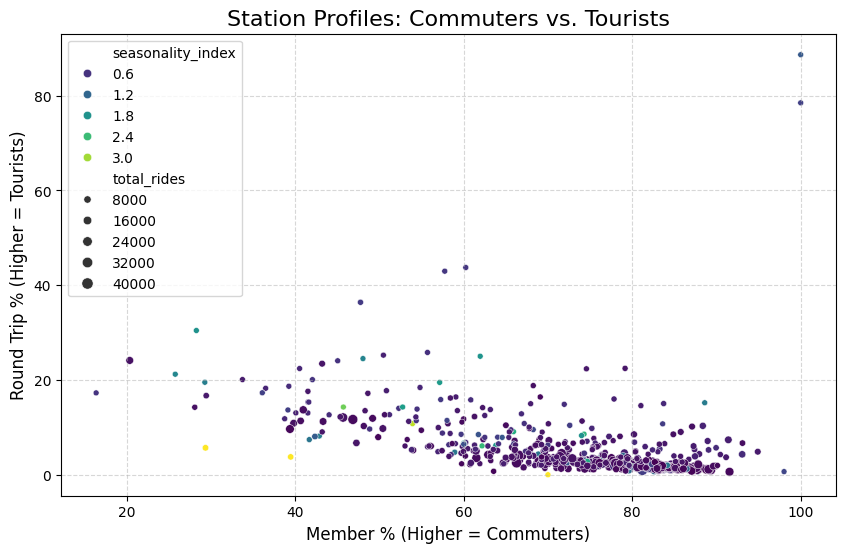

In [59]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=final_analysis,
    x="member_pct",
    y="round_trip_pct",
    size="total_rides",
    hue="seasonality_index",
    palette="viridis"
)

plt.title('Station Profiles: Commuters vs. Tourists', fontsize=16)
plt.xlabel('Member % (Higher = Commuters)', fontsize=12)
plt.ylabel('Round Trip % (Higher = Tourists)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

*Insight:*
- The higher % of memberships correlated with lower % of round trips. Which points to the conclusion that most people who are not members are not regualar commuters.

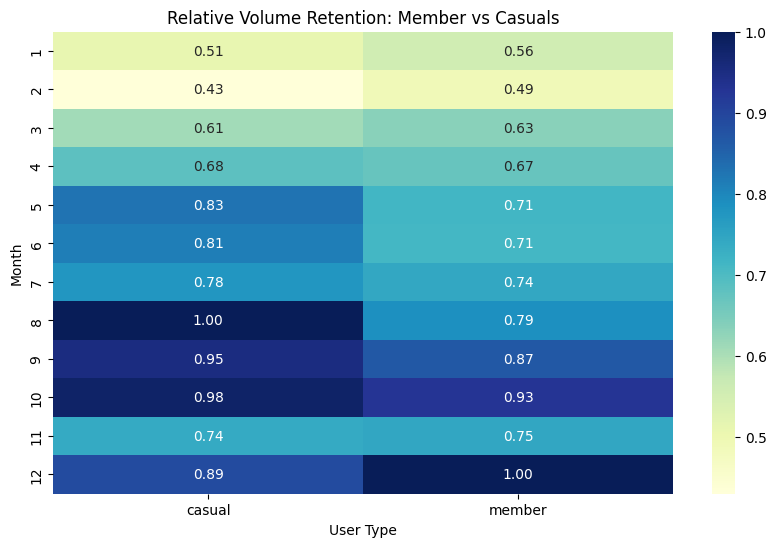

In [60]:
heat_data = df.groupby(["start_month", "member_casual"]).size().unstack()
heat_norm = heat_data.div(heat_data.max())

plt.figure(figsize=(10,6))
sns.heatmap(heat_norm, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Relative Volume Retention: Member vs Casuals")
plt.xlabel("User Type")
plt.ylabel("Month")
plt.show()

Look into the October-November drop.

In [61]:
monthly_user_type = df.groupby(['start_month', 'member_casual']).size().unstack()
retention_trends = monthly_user_type.pct_change() + 1 
print("Retention Rate from October to November:")
print(retention_trends.loc[11])

Retention Rate from October to November:
member_casual
casual    0.753941
member    0.804042
Name: 11, dtype: float64


Casual riders are 5% more likely ro "churn" as soon as the calendar hits November. Members are dedicated commuters who keep riding even with the change in season.
Casual retention still is quite high, they're most definitely un-subscribed residents that use bikes semi-regularly.

#### Onboarding Quality

I will bucket the ride duration and thne look at the "Return Rate" - how often does a ride starting at station A and ending at station B resul in another ride starting from station B within a short window?

In [62]:
bins = [0,3,15,30,float('inf')]
labels = ["<3 mins", "3-15 mins", "15-30 mins", "30+ mins"]
df["duration_bucket"] = pd.cut(df["trip_duration_min"], bins=bins, labels=labels)

onboarding_dist = df.groupby(["duration_bucket", "member_casual"]).size().unstack()
print(onboarding_dist)

member_casual    casual   member
duration_bucket                 
<3 mins           42831   327081
3-15 mins        546817  2592135
15-30 mins       258157   598489
30+ mins         145533   105037


/var/folders/r3/fhz0cy092rq1vdp607ycp5zc0000gn/T/ipykernel_2530/3034037671.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  onboarding_dist = df.groupby(["duration_bucket", "member_casual"]).size().unstack()


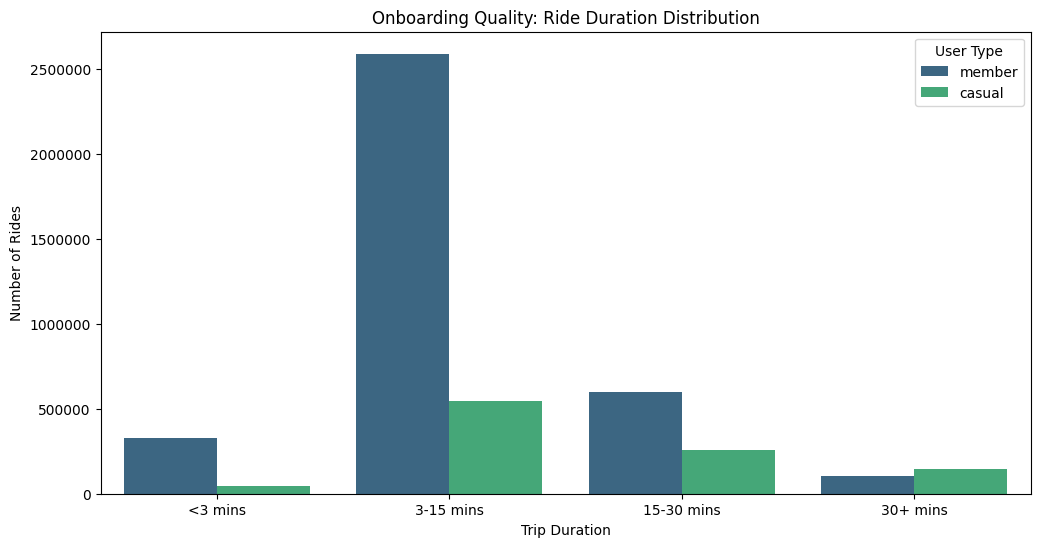

In [75]:
plt.figure(figsize=(12,6))
plt.style.use("seaborn-v0_8-muted")
ax1 = sns.countplot(data=df, x="duration_bucket", hue="member_casual", order=labels, palette="viridis")
plt.title("Onboarding Quality: Ride Duration Distribution")
plt.xlabel("Trip Duration")
plt.ylabel("Number of Rides")

plt.legend(title="User Type")

ax1.ticklabel_format(axis="y", style="plain")
plt.show()

3-15 minutes drive is the "sweet spot". It's long enough to enjoy the service but short enough to fell efficient. Those that take long trips 30+ minutes don't subscribe, might be because they use bikes only for rare long trips.

Look into <3 minutes ride. I can test if it's a technical failure or a last-mile success.